<a href="https://colab.research.google.com/github/Tanvi-diwakar/ML_projects/blob/main/experience_salary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PROBLEM STATEMENT**

salary and experience dataset is provided, create an ML model to predict new salary of people based on some different years of experience

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv('Salary_Data.csv')

In [19]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [20]:
X = df["YearsExperience"]
y = df["Salary"]

In [21]:
X.head()

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2


In [22]:
y.head()

,Salary
0,39343.0
1,46205.0
2,37731.0
3,43525.0
4,39891.0


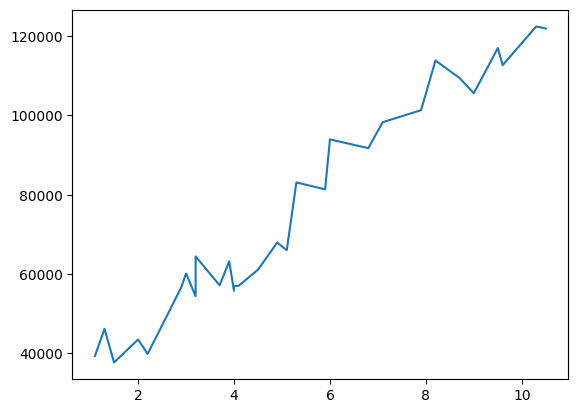

In [23]:
plt.plot(X,y)

In [24]:
X = np.array(X)
y = np.array(y)

In [25]:
def mean(X):
  return np.sum(X)/len(X)

In [26]:
def variance(X):
  mean_value = mean(X)
  return np.sum((X-mean_value)**2)/len(X)

In [27]:
def norm(X):
  mean_value = mean(X)
  variance_value = variance(X)
  return (X-mean_value)/np.sqrt(variance_value)

In [28]:
X_norm = norm(X)

In [29]:
X_norm

array([-1.51005294, -1.43837321, -1.36669348, -1.18749416, -1.11581443,
       -0.86493538, -0.82909552, -0.75741579, -0.75741579, -0.57821647,
       -0.50653674, -0.47069688, -0.47069688, -0.43485702, -0.29149756,
       -0.1481381 , -0.07645838, -0.00477865,  0.21026054,  0.2461004 ,
        0.53281931,  0.6403389 ,  0.92705781,  1.03457741,  1.21377673,
        1.32129632,  1.50049564,  1.5363355 ,  1.78721455,  1.85889428])

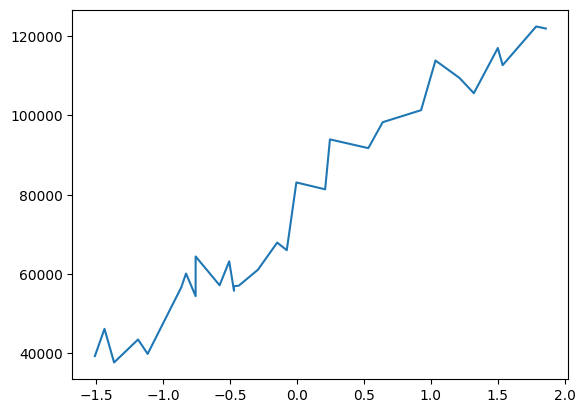

In [30]:
plt.plot(X_norm,y)

In [31]:
import random

In [32]:
class SimpleLR:
    def __init__(self, lr=0.1, max_iter=2000, threshold=1e-6):
        self.lr = lr
        self.max_iter = max_iter
        self.threshold = threshold
        self.weight = random.uniform(-1,1)
        self.bias = random.uniform(-1,1)
    def predict(self, X):
        return self.weight*X + self.bias
    def fit(self, X, Y):
        n = len(X)
        loss_history = []
        y_pred = self.predict(X)
        errors = Y-y_pred
        prev_loss = (1/(2*n)) * np.sum(errors**2)
        loss_history.append(prev_loss)
        for i in range(self.max_iter):
            w_grad = (1/n) * np.sum(errors*X)
            b_grad = (1/n) * np.sum(errors)
            self.weight += self.lr * w_grad
            self.bias += self.lr * b_grad
            y_pred = self.predict(X)
            errors = Y-y_pred
            curr_loss = (1/(2*n)) * np.sum(errors**2)
            if np.abs(curr_loss - prev_loss) < self.threshold:
                break
            prev_loss = curr_loss
            loss_history.append(curr_loss)
        return loss_history
    def plot(self, X, Y):
        y_pred = self.predict(X)
        plt.plot(X,Y)
        plt.plot(X,y_pred)

In [33]:
model = SimpleLR()

In [34]:
loss_history = model.fit(X_norm,y)

In [35]:
loss_history

[np.float64(3251504580.323603),
 np.float64(2636689450.475736),
 np.float64(2138689195.298962),
 np.float64(1735308988.605776),
 np.float64(1408571021.1842954),
 np.float64(1143913267.5728962),
 np.float64(929540487.1476626),
 np.float64(755898535.0032234),
 np.float64(615248553.7662275),
 np.float64(501322068.96426105),
 np.float64(409041616.27466804),
 np.float64(334294449.596098),
 np.float64(273749244.58645606),
 np.float64(224707628.52864614),
 np.float64(184983919.52182007),
 np.float64(152807715.2262909),
 np.float64(126744989.74691236),
 np.float64(105634182.10861571),
 np.float64(88534427.9215954),
 np.float64(74683627.030109),
 np.float64(63464478.30800504),
 np.float64(54376967.84310081),
 np.float64(47016084.366528355),
 np.float64(41053768.750504635),
 np.float64(36224293.101525396),
 np.float64(32312417.825852267),
 np.float64(29143798.85255701),
 np.float64(26577217.48418791),
 np.float64(24498286.57580889),
 np.float64(22814352.540021863),
 np.float64(21450365.971034408

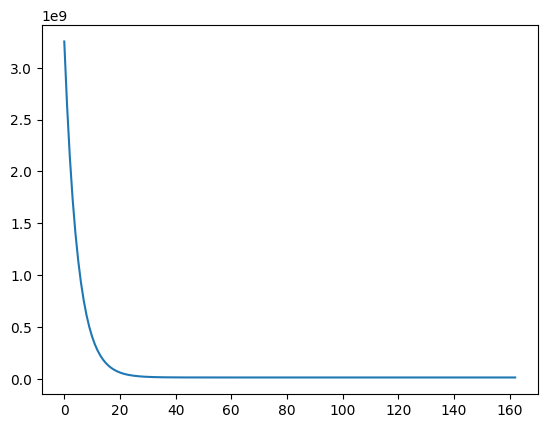

In [36]:
plt.plot(loss_history)

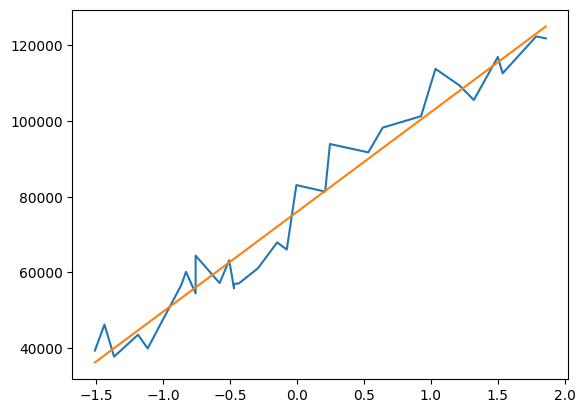

In [37]:
model.plot(X_norm,y)